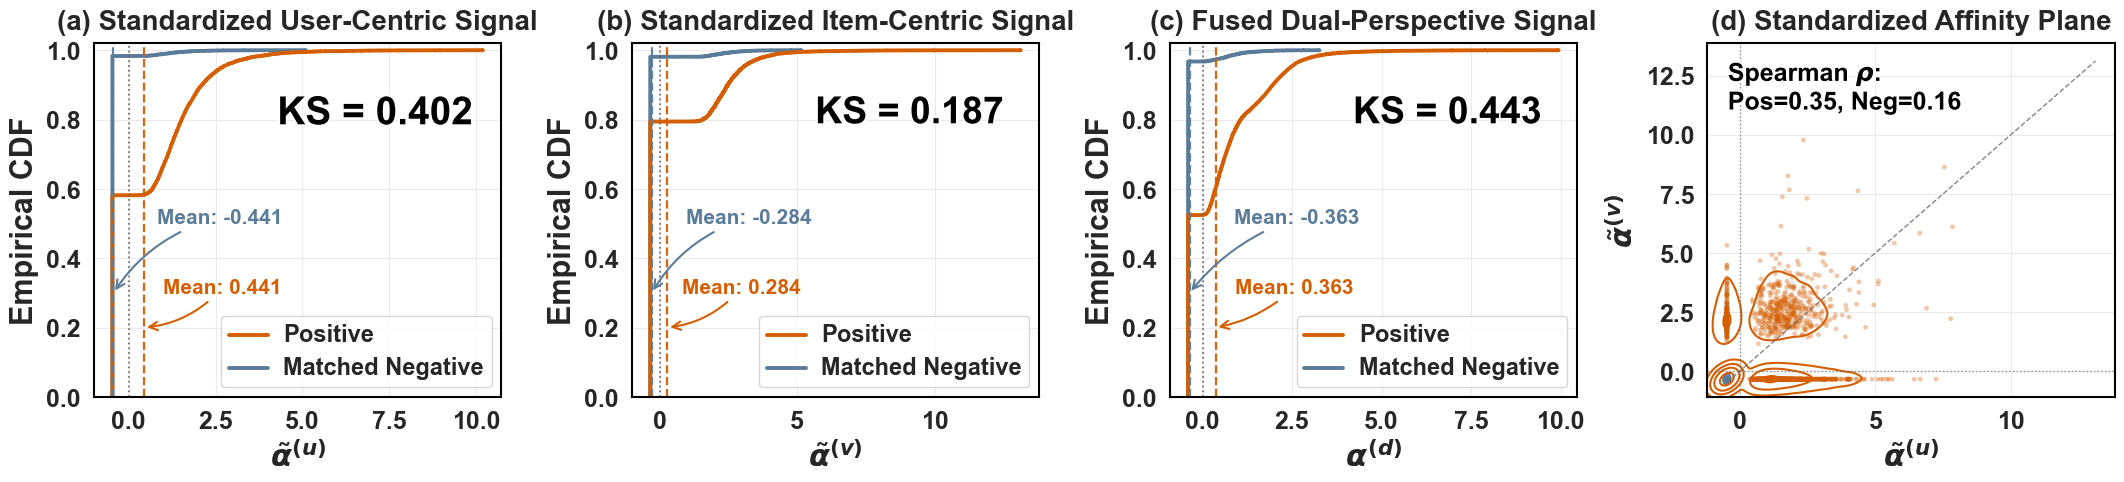

In [25]:
import os
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ks_2samp
import matplotlib.patheffects as path_effects

# ==========================================
# 1. 路径设置
# ==========================================
csv_path = os.path.join("analysis_outputs/perspective_dependence_tmall/tmall_perspective_affinity.csv")
plot_path = os.path.join("analysis_outputs/perspective_dependence_tmall/tmall_perspective_dependence_4panel_standardized.pdf")

# 读取数据
df = pd.read_csv(csv_path)

# ==========================================
# 2. 构造标准化单视角信号与融合信号
# ==========================================
mu_u = df["alpha_user"].mean()
std_u = df["alpha_user"].std()
mu_v = df["alpha_item"].mean()
std_v = df["alpha_item"].std()

if std_u < 1e-8:
  std_u = 1.0
if std_v < 1e-8:
  std_v = 1.0

df["alpha_user_z"] = (df["alpha_user"] - mu_u) / std_u
df["alpha_item_z"] = (df["alpha_item"] - mu_v) / std_v
df["alpha_fused"] = 0.5 * (df["alpha_user_z"] + df["alpha_item_z"])

# ==========================================
# 3. 统计量
# ==========================================
pos = df[df["label"] == "Positive"].copy()
neg = df[df["label"] == "Matched Negative"].copy()

def get_stats(col):
  pos_mean = pos[col].mean()
  neg_mean = neg[col].mean()
  pos_median = pos[col].median()
  neg_median = neg[col].median()
  ks = ks_2samp(pos[col], neg[col]).statistic
  return {
      "pos_mean": pos_mean,
      "neg_mean": neg_mean,
      "mean_gap": pos_mean - neg_mean,
      "pos_median": pos_median,
      "neg_median": neg_median,
      "median_gap": pos_median - neg_median,
      "ks": ks,
  }

stats_user = get_stats("alpha_user_z")
stats_item = get_stats("alpha_item_z")
stats_fused = get_stats("alpha_fused")

rho_pos = spearmanr(pos["alpha_user_z"], pos["alpha_item_z"]).statistic
rho_neg = spearmanr(neg["alpha_user_z"], neg["alpha_item_z"]).statistic

# ==========================================
# 4. 全局风格
# ==========================================
mpl.rcParams.update({
  "font.family": "serif",
  "font.serif": ["Times New Roman"],
  "font.weight": "bold",
  "axes.labelweight": "bold",
  "axes.titleweight": "bold",
  "font.size": 14,
  "axes.labelsize": 18,
  "axes.titlesize": 20,
  "xtick.labelsize": 15,
  "ytick.labelsize": 15,
  "legend.fontsize": 14,
  "axes.spines.top": False,
  "axes.spines.right": False,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
})

sns.set_style("whitegrid", {
  "axes.grid": True,
  "grid.color": "#EAEAEA",
  "axes.edgecolor": "black",
  "axes.linewidth": 1.5
})

pos_color = "#D55E00"
neg_color = "#5B7C99"
line_gray = "#666666"

# ==========================================
# 5. 一行四列
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(21.5, 5.2))

# ------------------------------------------
# (a) Standardized User-Centric Signal
# ------------------------------------------
ax = axes[0]
sns.ecdfplot(
  data=df,
  x="alpha_user_z",
  hue="label",
  linewidth=2.8,
  palette={"Positive": pos_color, "Matched Negative": neg_color},
  ax=ax,
)

ax.axvline(0.0, color=line_gray, linestyle=":", linewidth=1.3, alpha=0.9)
ax.axvline(stats_user["pos_mean"], color=pos_color, linestyle="--", linewidth=1.6, alpha=0.95)
ax.axvline(stats_user["neg_mean"], color=neg_color, linestyle="--", linewidth=1.6, alpha=0.95)

ax.annotate(
  f'Mean: {stats_user["pos_mean"]:.3f}',
  xy=(stats_user["pos_mean"], 0.20),
  xytext=(stats_user["pos_mean"] + 0.55, 0.30),
  color=pos_color,
  fontweight='bold',
  fontsize=15,
  arrowprops=dict(
      arrowstyle="->",
      color=pos_color,
      lw=1.5,
      connectionstyle="arc3,rad=-0.2"
  )
)

ax.annotate(
  f'Mean: {stats_user["neg_mean"]:.3f}',
  xy=(stats_user["neg_mean"], 0.30),
  xytext=(stats_user["neg_mean"] + 1.25, 0.50),
  color=neg_color,
  fontweight='bold',
  fontsize=15,
  arrowprops=dict(
      arrowstyle="->",
      color=neg_color,
      lw=1.5,
      connectionstyle="arc3,rad=0.2"
  )
)

text = ax.text(
  0.45, 0.85,
  rf"KS = {stats_user['ks']:.3f}",
  transform=ax.transAxes, ha="left", va="top",
  fontsize=28, fontweight='bold', color='black', zorder=10
)
text.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])

ax.set_title(r"(a) Standardized User-Centric Signal", pad=10)
ax.set_xlabel(r"$\tilde{\alpha}^{(u)}$", fontsize=22, labelpad=5)
ax.set_ylabel("Empirical CDF", fontsize=22, labelpad=5)
ax.set_ylim(0, 1.02)
ax.legend_.set_title(None)
plt.setp(ax.get_legend().get_texts(), fontsize=17, fontweight='bold')

# ------------------------------------------
# (b) Standardized Item-Centric Signal
# ------------------------------------------
ax = axes[1]
sns.ecdfplot(
  data=df,
  x="alpha_item_z",
  hue="label",
  linewidth=2.8,
  palette={"Positive": pos_color, "Matched Negative": neg_color},
  ax=ax,
)

ax.axvline(0.0, color=line_gray, linestyle=":", linewidth=1.3, alpha=0.9)
ax.axvline(stats_item["pos_mean"], color=pos_color, linestyle="--", linewidth=1.6, alpha=0.95)
ax.axvline(stats_item["neg_mean"], color=neg_color, linestyle="--", linewidth=1.6, alpha=0.95)

ax.annotate(
  f'Mean: {stats_item["pos_mean"]:.3f}',
  xy=(stats_item["pos_mean"], 0.20),
  xytext=(stats_item["pos_mean"] + 0.55, 0.30),
  color=pos_color,
  fontweight='bold',
  fontsize=15,
  arrowprops=dict(
      arrowstyle="->",
      color=pos_color,
      lw=1.5,
      connectionstyle="arc3,rad=-0.2"
  )
)

ax.annotate(
  f'Mean: {stats_item["neg_mean"]:.3f}',
  xy=(stats_item["neg_mean"], 0.30),
  xytext=(stats_item["neg_mean"] + 1.25, 0.50),
  color=neg_color,
  fontweight='bold',
  fontsize=15,
  arrowprops=dict(
      arrowstyle="->",
      color=neg_color,
      lw=1.5,
      connectionstyle="arc3,rad=0.2"
  )
)

text = ax.text(
  0.45, 0.85,
  rf"KS = {stats_item['ks']:.3f}",
  transform=ax.transAxes, ha="left", va="top",
  fontsize=27, fontweight='bold', color='black', zorder=10
)
text.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])

ax.set_title(r"(b) Standardized Item-Centric Signal", pad=10)
ax.set_xlabel(r"$\tilde{\alpha}^{(v)}$", fontsize=22, labelpad=5)
ax.set_ylabel("Empirical CDF", fontsize=22, labelpad=5)
ax.set_ylim(0, 1.02)

ax.legend_.set_title(None)
ax.legend_._set_loc(4)
plt.setp(ax.get_legend().get_texts(), fontsize=17, fontweight='bold')

# ------------------------------------------
# (c) Standardized Perspective-Affinity Plane
# ------------------------------------------
ax = axes[3]
scatter_n = min(3000, len(pos), len(neg))
pos_scatter = pos.sample(n=scatter_n, random_state=2026)
neg_scatter = neg.sample(n=scatter_n, random_state=2026)

ax.scatter(
  neg_scatter["alpha_user_z"], neg_scatter["alpha_item_z"],
  s=12, alpha=0.15, color=neg_color, edgecolors='none', rasterized=True
)
ax.scatter(
  pos_scatter["alpha_user_z"], pos_scatter["alpha_item_z"],
  s=12, alpha=0.35, color=pos_color, edgecolors='none', rasterized=True
)

sns.kdeplot(
  data=neg, x="alpha_user_z", y="alpha_item_z",
  levels=5, color=neg_color, linewidths=1.5, ax=ax
)
sns.kdeplot(
  data=pos, x="alpha_user_z", y="alpha_item_z",
  levels=5, color=pos_color, linewidths=1.5, ax=ax
)

xmin = min(df["alpha_user_z"].min(), df["alpha_item_z"].min())
xmax = max(df["alpha_user_z"].max(), df["alpha_item_z"].max())
ax.plot([xmin, xmax], [xmin, xmax], ls="--", lw=1.0, color=line_gray, alpha=0.8)
ax.axvline(0.0, color=line_gray, linestyle=":", linewidth=1.0, alpha=0.7)
ax.axhline(0.0, color=line_gray, linestyle=":", linewidth=1.0, alpha=0.7)

text = ax.text(
  0.05, 0.95,
  rf"Spearman $\rho$:" + "\n" + rf"Pos={rho_pos:.2f}, Neg={rho_neg:.2f}",
  transform=ax.transAxes, ha="left", va="top",
  fontsize=18, fontweight='bold', color='black', zorder=10
)
text.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])

ax.set_title("(d) Standardized Affinity Plane", pad=10)
ax.set_xlabel(r"$\tilde{\alpha}^{(u)}$", fontsize=22, labelpad=5)
ax.set_ylabel(r"$\tilde{\alpha}^{(v)}$", fontsize=22, labelpad=5)

# ------------------------------------------
# (d) Fused Dual-Perspective Signal
# ------------------------------------------
ax = axes[2]
sns.ecdfplot(
  data=df,
  x="alpha_fused",
  hue="label",
  linewidth=2.8,
  palette={"Positive": pos_color, "Matched Negative": neg_color},
  ax=ax,
)

ax.axvline(0.0, color=line_gray, linestyle=":", linewidth=1.3, alpha=0.9)
ax.axvline(stats_fused["pos_mean"], color=pos_color, linestyle="--", linewidth=1.6, alpha=0.95)
ax.axvline(stats_fused["neg_mean"], color=neg_color, linestyle="--", linewidth=1.6, alpha=0.95)

ax.annotate(
  f'Mean: {stats_fused["pos_mean"]:.3f}',
  xy=(stats_fused["pos_mean"], 0.20),
  xytext=(stats_fused["pos_mean"] + 0.55, 0.30),
  color=pos_color,
  fontweight='bold',
  fontsize=15,
  arrowprops=dict(
      arrowstyle="->",
      color=pos_color,
      lw=1.5,
      connectionstyle="arc3,rad=-0.15"
  )
)

ax.annotate(
  f'Mean: {stats_fused["neg_mean"]:.3f}',
  xy=(stats_fused["neg_mean"], 0.30),
  xytext=(stats_fused["neg_mean"] + 1.25, 0.50),
  color=neg_color,
  fontweight='bold',
  fontsize=15,
  arrowprops=dict(
      arrowstyle="->",
      color=neg_color,
      lw=1.5,
      connectionstyle="arc3,rad=0.15"
  )
)

text = ax.text(
  0.45, 0.85,
  rf"KS = {stats_fused['ks']:.3f}",
  transform=ax.transAxes, ha="left", va="top",
  fontsize=27, fontweight='bold', color='black', zorder=10
)
text.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])

ax.set_title("(c) Fused Dual-Perspective Signal", pad=10)
ax.set_xlabel(r"$\alpha^{(d)}$", fontsize=22, labelpad=5)
ax.set_ylabel("Empirical CDF", fontsize=22, labelpad=5)
ax.set_ylim(0, 1.02)

ax.legend_.set_title(None)
ax.legend_._set_loc(4)
plt.setp(ax.get_legend().get_texts(), fontsize=17, fontweight='bold')

# ------------------------------------------
# 6. 统一美化
# ------------------------------------------
for ax_item in axes:
  ax_item.tick_params(width=1.5, length=6, labelsize=18)
  for spine in ax_item.spines.values():
      spine.set_linewidth(1.5)

fig.subplots_adjust(wspace=0.32, left=0.05, right=0.99, top=0.88, bottom=0.2)
fig.savefig("tmall_affinity_analysis.pdf", bbox_inches="tight", dpi=300)
plt.show()